<a href="https://colab.research.google.com/github/tablitomax-dev/AionUi/blob/main/Titanic_desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Machine Learning Supervisionado: Titanic

**Curso / disciplina:** preencher pelo grupo  
**Integrantes:** preencher pelo grupo  
**Data:** preencher pelo grupo

## Objetivo

Neste notebook, desenvolvemos uma solução de **classificação supervisionada** para prever quais passageiros sobreviveram ao naufrágio do Titanic, utilizando o conjunto de dados disponibilizado pelo Kaggle.[web:12][web:14]

O foco principal deste trabalho não é apenas obter uma pontuação alta, mas sim aplicar corretamente todas as etapas de um projeto clássico de Machine Learning: leitura dos dados, análise exploratória, tratamento, modelagem, avaliação e geração do arquivo de submissão.[web:12]

## 1. Entendimento do problema

O problema consiste em prever a variável-alvo `Survived`, que indica se um passageiro sobreviveu (`1`) ou não (`0`). Isso caracteriza um problema de **classificação binária supervisionada**.

Do ponto de vista metodológico, vamos seguir o fluxo abaixo:

1. Ler as bases `train.csv` e `test.csv`.
2. Realizar análise exploratória dos dados (EDA).
3. Tratar valores ausentes e preparar as variáveis.
4. Treinar e comparar modelos de classificação.
5. Escolher um modelo final.
6. Gerar o arquivo `submission.csv` no formato exigido pelo Kaggle, com `PassengerId` e `Survived`.[web:12][web:14]

In [1]:
# 2. Importação das bibliotecas

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

## 2. Leitura dos dados

De acordo com o desafio do Kaggle, a base de treino contém a variável `Survived`, enquanto a base de teste é usada para gerar as previsões finais.[web:14]

> **Importante:** antes de executar este notebook, faça o download de `train.csv` e `test.csv` na página da competição e coloque os arquivos na mesma pasta do notebook.[web:12][web:14]

In [2]:
# 3. Leitura das bases e funções utilitárias de normalização

import difflib


def padronizar_colunas(df):
    """Remove espaços externos dos nomes de colunas (mantém o original)."""
    df.columns = df.columns.str.strip()
    return df


def _norm(nome):
    """Chave de comparação: minúsculas, sem espaços (internos ou externos)."""
    return str(nome).strip().lower().replace(" ", "")


def resolver_coluna(df, nome):
    """
    Encontra o nome REAL de uma coluna no DataFrame de forma tolerante:
      - ignora maiúsculas/minúsculas;
      - ignora espaços externos e internos (ex.: 'Passenger Id' == 'passengerid');
      - tolera pequenos erros de digitação (via difflib).
    """
    alvo = _norm(nome)
    candidatas = {_norm(c): c for c in df.columns}

    # 1) correspondência exata após normalização
    if alvo in candidatas:
        return candidatas[alvo]

    # 2) correspondência aproximada (typos)
    proximas = difflib.get_close_matches(alvo, list(candidatas), n=1, cutoff=0.8)
    if proximas:
        return candidatas[proximas[0]]

    raise KeyError(
        f"A coluna '{nome}' não existe no DataFrame. "
        f"Colunas disponíveis: {list(df.columns)}"
    )


def resolver_colunas(df, nomes):
    """Mesma ideia de resolver_coluna, mas para uma LISTA de colunas."""
    return [resolver_coluna(df, n) for n in nomes]


train = padronizar_colunas(pd.read_csv("train.csv", sep=","))
test = padronizar_colunas(pd.read_csv("test.csv", sep=","))

print("Dimensão da base de treino:", train.shape)
print("Dimensão da base de teste:", test.shape)
print("\n🔍 Colunas disponíveis:", list(train.columns))


Dimensão da base de treino: (891, 12)
Dimensão da base de teste: (418, 11)

🔍 Colunas disponíveis: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
# Informações gerais

print("Informações da base de treino")
display(train.info())

print("Informações da base de teste")
display(test.info())

Informações da base de treino
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

Informações da base de teste
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


None

## 3. Dicionário resumido das variáveis

As colunas normalmente utilizadas nesse desafio incluem informações demográficas, econômicas e familiares do passageiro, como sexo, idade, classe da passagem, número de irmãos/cônjuges, número de pais/filhos, tarifa e local de embarque.[web:14][web:15]

Variáveis principais deste notebook:

- `Survived`: variável-alvo.
- `Pclass`: classe da passagem.
- `Sex`: sexo do passageiro.
- `Age`: idade.
- `SibSp`: número de irmãos/cônjuges a bordo.
- `Parch`: número de pais/filhos a bordo.
- `Fare`: tarifa paga.
- `Embarked`: porto de embarque.

## 4. Análise exploratória dos dados (EDA)

A análise exploratória é importante para entender a distribuição da variável-alvo, identificar padrões iniciais e detectar problemas como valores ausentes e possíveis inconsistências.[web:13][web:15]

Nesta etapa, vamos observar:

1. Como a variável `Survived` está distribuída.
2. Como a sobrevivência se relaciona com sexo, classe e idade.
3. Quais colunas possuem valores ausentes.

In [5]:
# 4.1 Estatísticas descritivas

display(train.describe(include="all"))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


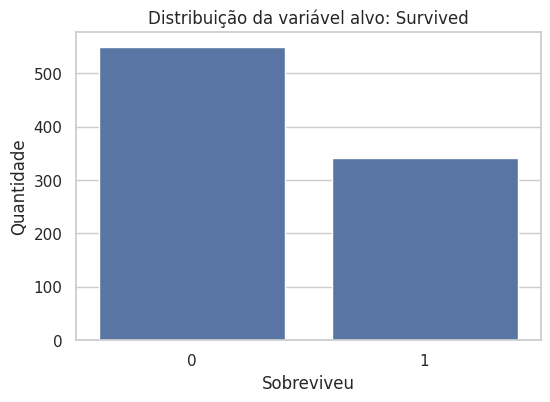

Taxa média de sobrevivência na base de treino: 38.38%


In [6]:
# 4.2 Distribuição da variável alvo

col_survived = resolver_coluna(train, "survived")  # tolera "Survived", "SURVIVED", " survived "

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x=col_survived)
plt.title(f"Distribuição da variável alvo: {col_survived}")
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")
plt.show()

survival_rate = train[col_survived].mean()
print(f"Taxa média de sobrevivência na base de treino: {survival_rate:.2%}")


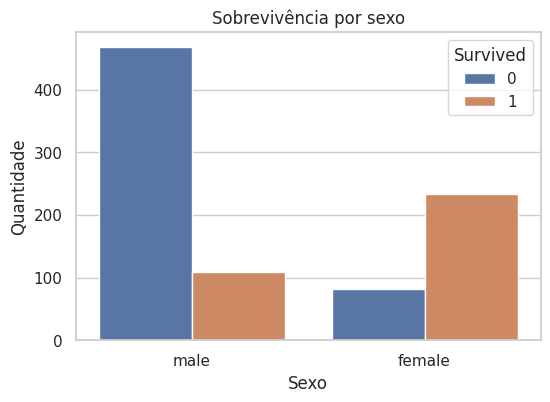

,taxa_sobrevivencia
Sex,
female,0.742038
male,0.188908


In [7]:
# 4.3 Sobrevivência por sexo

col_sex = resolver_coluna(train, "sex")
col_surv = resolver_coluna(train, "survived")

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x=col_sex, hue=col_surv)
plt.title("Sobrevivência por sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")
plt.show()

sex_survival = train.groupby(col_sex)[col_surv].mean().sort_values(ascending=False)
display(sex_survival.to_frame("taxa_sobrevivencia"))


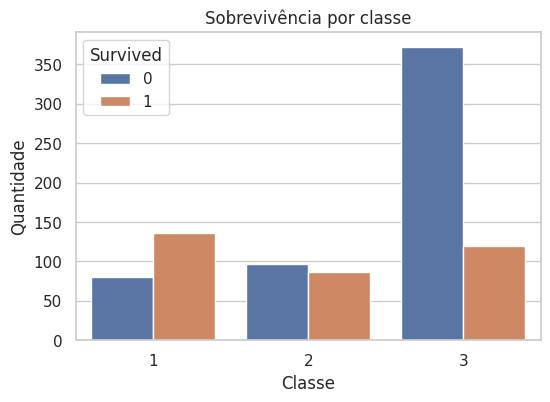

,taxa_sobrevivencia
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [8]:
# 4.4 Sobrevivência por classe

col_pclass = resolver_coluna(train, "pclass")
col_surv = resolver_coluna(train, "survived")

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x=col_pclass, hue=col_surv)
plt.title("Sobrevivência por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

pclass_survival = train.groupby(col_pclass)[col_surv].mean().sort_values(ascending=False)
display(pclass_survival.to_frame("taxa_sobrevivencia"))


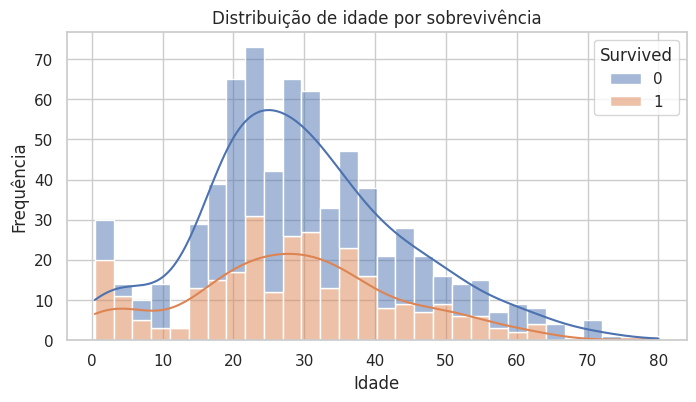

In [9]:
# 4.5 Distribuição da idade por sobrevivência

col_age = resolver_coluna(train, "age")
col_surv = resolver_coluna(train, "survived")

plt.figure(figsize=(8, 4))
sns.histplot(data=train, x=col_age, hue=col_surv, kde=True, bins=30, multiple="stack")
plt.title("Distribuição de idade por sobrevivência")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()


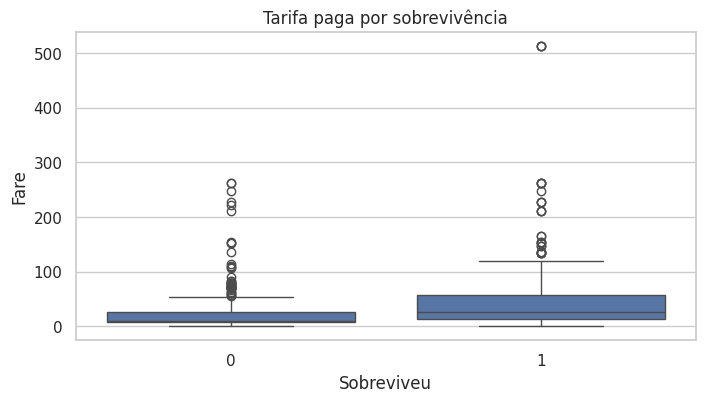

In [10]:
# 4.6 Distribuição da tarifa

col_surv = resolver_coluna(train, "survived")
col_fare = resolver_coluna(train, "fare")

plt.figure(figsize=(8, 4))
sns.boxplot(data=train, x=col_surv, y=col_fare)
plt.title("Tarifa paga por sobrevivência")
plt.xlabel("Sobreviveu")
plt.ylabel("Fare")
plt.show()


In [11]:
# 4.7 Valores ausentes

def tabela_missing(df):
    missing = df.isnull().sum()
    percent = df.isnull().mean() * 100
    tabela = pd.DataFrame({
        "missing": missing,
        "percentual": percent
    }).sort_values("percentual", ascending=False)
    return tabela[tabela["missing"] > 0]

print("Valores ausentes - treino")
display(tabela_missing(train))

print("Valores ausentes - teste")
display(tabela_missing(test))

Valores ausentes - treino


,missing,percentual
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


Valores ausentes - teste


,missing,percentual
Cabin,327,78.229665
Age,86,20.574163
Fare,1,0.239234


### Comentários da EDA

Com base em análises recorrentes do desafio Titanic, é comum observar muitos valores ausentes em `Cabin`, vários valores ausentes em `Age` e poucos em `Embarked`.[web:13][web:20]

Além disso, `Sex` e `Pclass` costumam apresentar forte relação com a sobrevivência, o que faz sentido histórico e estatístico para esse problema.[web:15][web:16]

> **Sugestão para o relatório:** após executar os gráficos, substituam este texto por interpretações escritas por vocês, comentando o que de fato apareceu nos resultados.

## 5. Preparação dos dados

Nesta etapa, vamos definir quais colunas usar, como tratar valores ausentes e como transformar variáveis categóricas em formato numérico.

### Decisões adotadas

1. Vamos usar as colunas `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare` e `Embarked`.
2. Vamos remover `Name`, `Ticket` e `Cabin` da abordagem inicial para manter um pipeline didático e objetivo; `Cabin`, em particular, costuma ter muitos valores ausentes.[web:13]
3. Valores ausentes numéricos serão preenchidos com a **mediana**.
4. Valores ausentes categóricos serão preenchidos com a **moda**.
5. Variáveis categóricas serão codificadas com `OneHotEncoder`.

In [12]:
# 5.1 Seleção de colunas

# Os nomes podem ser escritos em qualquer formato (maiúsculas/minúsculas,
# com ou sem espaços, com pequenos erros de digitação). O resolver_colunas
# encontra o nome real no DataFrame.
nomes_features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
nome_target = "survived"

features = resolver_colunas(train, nomes_features)
target = resolver_coluna(train, nome_target)

X = train[features].copy()
y = train[target].copy()
X_test = test[resolver_colunas(test, nomes_features)].copy()

num_features = resolver_colunas(train, ["age", "sibsp", "parch", "fare", "pclass"])
cat_features = resolver_colunas(train, ["sex", "embarked"])

print("Features usadas:", features)
print("Target:", target)
print("Numéricas:", num_features)
print("Categóricas:", cat_features)


Features usadas: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target: Survived
Numéricas: ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass']
Categóricas: ['Sex', 'Embarked']


In [13]:
# 5.2 Separação treino/validação

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (712, 7)
X_valid: (179, 7)
y_train: (712,)
y_valid: (179,)


In [14]:
# 5.3 Pipeline de pré-processamento

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

## 6. Treinamento e comparação de modelos

O enunciado pede pelo menos um modelo supervisionado, mas recomenda comparar dois ou mais algoritmos. Por isso, vamos testar três modelos clássicos:[web:12]

1. **Regressão Logística**: bom baseline, simples e interpretável.
2. **Árvore de Decisão**: fácil de explicar, mas pode sofrer overfitting.
3. **Random Forest**: costuma melhorar a generalização ao combinar várias árvores.

In [15]:
# 6.1 Definição dos modelos

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE)
}

In [16]:
# 6.2 Treinamento e avaliação na validação

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)

    acc = accuracy_score(y_valid, preds)
    f1 = f1_score(y_valid, preds)

    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_score": f1
    })

    fitted_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="f1_score", ascending=False).reset_index(drop=True)
display(results_df)

,modelo,accuracy,f1_score
0,Decision Tree,0.804469,0.736842
1,Random Forest,0.804469,0.728682
2,Logistic Regression,0.804469,0.724409


In [17]:
# 6.3 Validação cruzada opcional para reforçar a análise

cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
    cv_results.append({
        "modelo": name,
        "cv_accuracy_media": scores.mean(),
        "cv_accuracy_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="cv_accuracy_media", ascending=False).reset_index(drop=True)
display(cv_results_df)

,modelo,cv_accuracy_media,cv_accuracy_std
0,Random Forest,0.809234,0.025107
1,Logistic Regression,0.787892,0.019760
2,Decision Tree,0.782299,0.029546


## 7. Escolha do melhor modelo

Neste ponto, o grupo deve escolher o modelo final com base nas métricas e na capacidade de justificar a escolha. Em muitos casos, o Random Forest apresenta desempenho competitivo nesse desafio, mas essa decisão deve ser confirmada pelos resultados obtidos na execução do notebook.[web:16]

Como regra didática:

- Se dois modelos tiverem desempenho muito parecido, pode ser melhor escolher o mais simples de explicar.
- Se um modelo tiver vantagem consistente em `accuracy` e `f1_score`, ele pode ser adotado como modelo final.

In [18]:
# 7.1 Seleção automática do melhor modelo pelo F1-score

best_model_name = results_df.loc[0, "modelo"]
best_pipeline = fitted_pipelines[best_model_name]

print("Melhor modelo com base no F1-score da validação:", best_model_name)

Melhor modelo com base no F1-score da validação: Decision Tree


In [19]:
# 7.2 Relatório de classificação

valid_preds = best_pipeline.predict(X_valid)

print(classification_report(y_valid, valid_preds))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



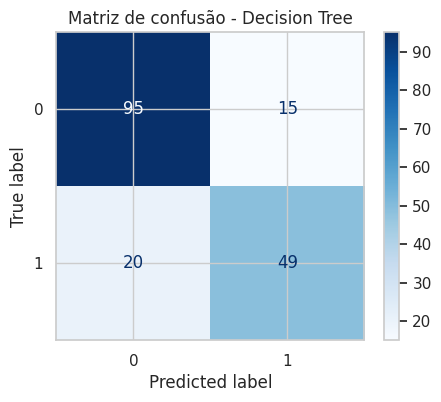

In [20]:
# 7.3 Matriz de confusão

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_valid, valid_preds, ax=ax, cmap="Blues")
plt.title(f"Matriz de confusão - {best_model_name}")
plt.show()

## 8. Importância das variáveis

O enunciado recomenda, quando possível, avaliar a importância das variáveis. Isso é especialmente útil quando o modelo final for baseado em árvores, como Decision Tree ou Random Forest.[web:12]

Se o melhor modelo não for baseado em árvores, esta seção pode ser mantida como análise complementar com o Random Forest.

In [21]:
# 8.1 Importância das variáveis para modelos baseados em árvore

rf_pipeline = fitted_pipelines["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

encoded_cat_names = rf_preprocessor.named_transformers_["cat"]    .named_steps["onehot"]    .get_feature_names_out(cat_features)

all_feature_names = num_features + list(encoded_cat_names)

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(feature_importance_df.head(15))

,feature,importance
3,Fare,0.260850
0,Age,0.248100
6,Sex_male,0.165488
5,Sex_female,0.121741
4,Pclass,0.082342
1,SibSp,0.048457
2,Parch,0.037486
9,Embarked_S,0.015530
7,Embarked_C,0.010495
8,Embarked_Q,0.009510


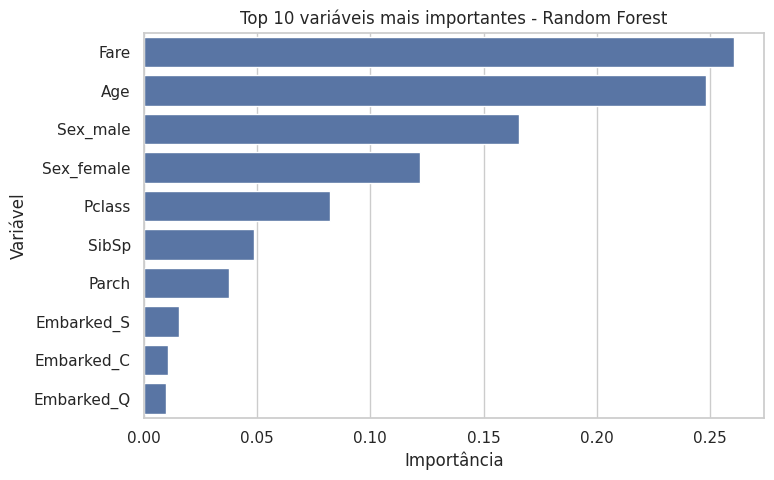

In [22]:
# 8.2 Gráfico das importâncias

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df.head(10), x="importance", y="feature")
plt.title("Top 10 variáveis mais importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

## 9. Treinamento final com toda a base de treino

Depois de escolher o modelo final, o passo correto é treiná-lo novamente usando toda a base `train.csv`, para então gerar as previsões da base `test.csv`.[web:14][web:15]

In [23]:
# 9.1 Definição do modelo final

final_model_lookup = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE)
}

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model_lookup[best_model_name])
])

final_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [24]:
# 9.2 Previsões na base de teste

test_preds = final_pipeline.predict(X_test)

col_passenger_id = resolver_coluna(test, "passengerid")
col_survived_out = "Survived"  # nome exigido pelo Kaggle no arquivo de submissão

submission = pd.DataFrame({
    col_passenger_id: test[col_passenger_id],
    col_survived_out: test_preds.astype(int)
})

display(submission.head())
print("Formato do arquivo de submissão:", submission.shape)


,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,1


Formato do arquivo de submissão: (418, 2)


In [25]:
# 9.3 Geração do arquivo final

submission.to_csv("submission.csv", index=False)
print("Arquivo 'submission.csv' gerado com sucesso.")

Arquivo 'submission.csv' gerado com sucesso.


## 10. Submissão no Kaggle

Segundo a página da competição, o arquivo de submissão deve ser um CSV com cabeçalho e exatamente **418 previsões** para a base de teste, além de seguir o formato esperado pelo desafio.[web:12]

Passos para submissão:

1. Acessar a página da competição Titanic no Kaggle.
2. Clicar em **Submit Predictions**.
3. Enviar o arquivo `submission.csv` gerado neste notebook.
4. Registrar uma captura de tela com o score obtido, pois isso faz parte dos entregáveis do trabalho.[web:12]

## 11. Conclusão

Neste projeto, aplicamos um fluxo completo de Machine Learning supervisionado para um problema de classificação binária. O trabalho incluiu leitura dos dados, EDA, tratamento de ausências, transformação de variáveis, comparação de modelos, avaliação e geração do arquivo final de submissão.[web:12][web:14]

### Pontos que podem ser destacados pelo grupo na versão final

- Quais variáveis pareceram mais relevantes para a sobrevivência.
- Qual modelo apresentou melhor equilíbrio entre simplicidade e desempenho.
- Quais limitações ainda existem na solução.
- Quais melhorias futuras poderiam ser testadas, como engenharia de atributos com `Title`, `FamilySize` ou uso mais elaborado de `Cabin`.[web:20]

## 12. Checklist final da entrega

Antes de entregar, confirmem:

- [ ] O notebook executa do início ao fim sem erros.
- [ ] As células estão em ordem lógica.
- [ ] O texto explica as decisões mais importantes.
- [ ] O arquivo `submission.csv` foi gerado.
- [ ] A submissão no Kaggle foi realizada.
- [ ] Foi salva a captura de tela com o resultado da competição.